##Problem statement:To predict which employees are likely to leave.

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [4]:
df=pd.read_csv("/content/HR_attrition.csv.csv")

In [5]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [8]:
df.shape

(1470, 35)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.drop('EmployeeCount', axis='columns', inplace=True)
df.drop('Over18', axis='columns', inplace=True )

In [12]:
## Handle null values

df.isnull().sum()
#Ensures that the dataset is clean.

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeNumber,0
EnvironmentSatisfaction,0


In [13]:
## Duplicate check

df.duplicated().sum()

np.int64(0)

##Split Data into Categorical and Numerical Col

In [14]:
from pandas.core.arrays import categorical
## Divide the columns based on the data type

categorical_columns = df.select_dtypes(include=["object"])
numerical_columns = df.select_dtypes(exclude=["object"])

In [15]:
categorical_columns

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No
...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,No


In [16]:
numerical_columns

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,2,94,3,2,4,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,2,3,61,2,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,4,4,92,2,1,3,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,5,4,56,3,1,3,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,7,1,40,3,1,2,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,2061,3,41,4,2,4,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,2062,4,42,2,3,1,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,2064,2,87,4,2,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,2065,4,63,2,2,2,...,4,80,0,17,3,2,9,6,0,8


In [17]:
for i in categorical_columns:
  print(df[i].value_counts())
  print("--"*20)


Attrition
No     1233
Yes     237
Name: count, dtype: int64
----------------------------------------
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
----------------------------------------
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
----------------------------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
----------------------------------------
Gender
Male      882
Female    588
Name: count, dtype: int64
----------------------------------------
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Rese

##Outliers

In [18]:
## Outlier detection

def outlier_detection(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [19]:
for col in numerical_columns:
  df = outlier_detection(df, col)

In [21]:
df.shape

(699, 33)

##univariate and bivariate analysis

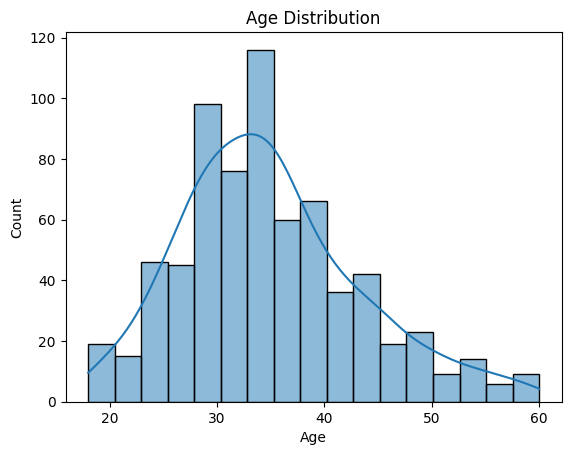

In [22]:
import matplotlib.pyplot as plt
# example: age distribution

plt.figure()
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

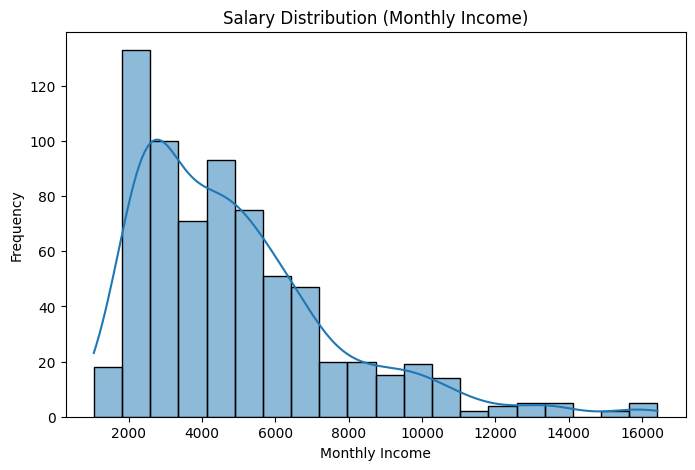

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyIncome'], kde=True)

plt.title("Salary Distribution (Monthly Income)")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()

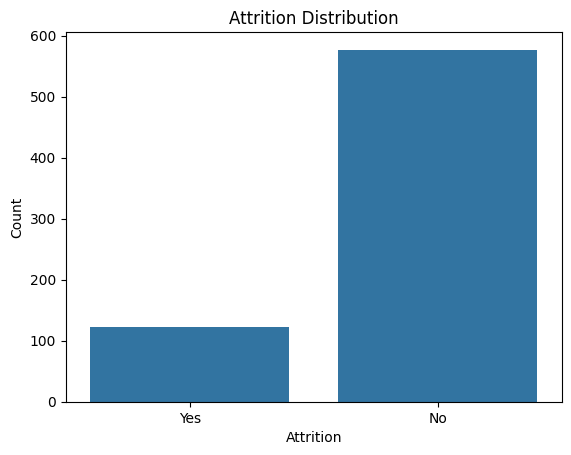

In [24]:
sns.countplot(x='Attrition', data=df)

plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.show()

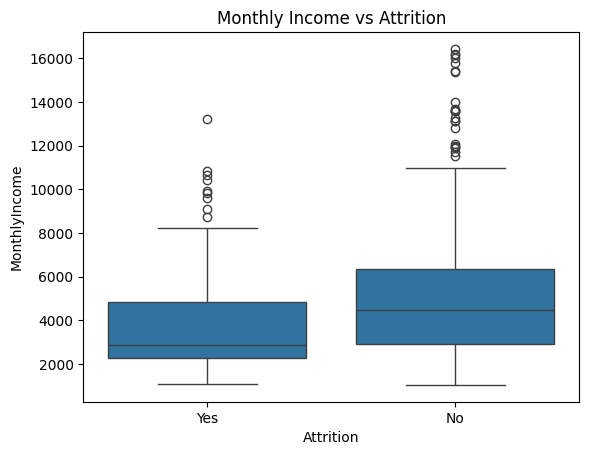

In [25]:
# Bivariate (salary vs attrition)

plt.figure()
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

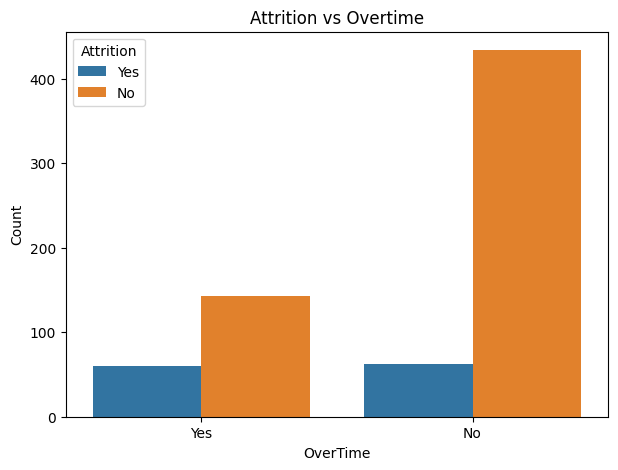

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title("Attrition vs Overtime")
plt.xlabel("OverTime")
plt.ylabel("Count")

plt.show()

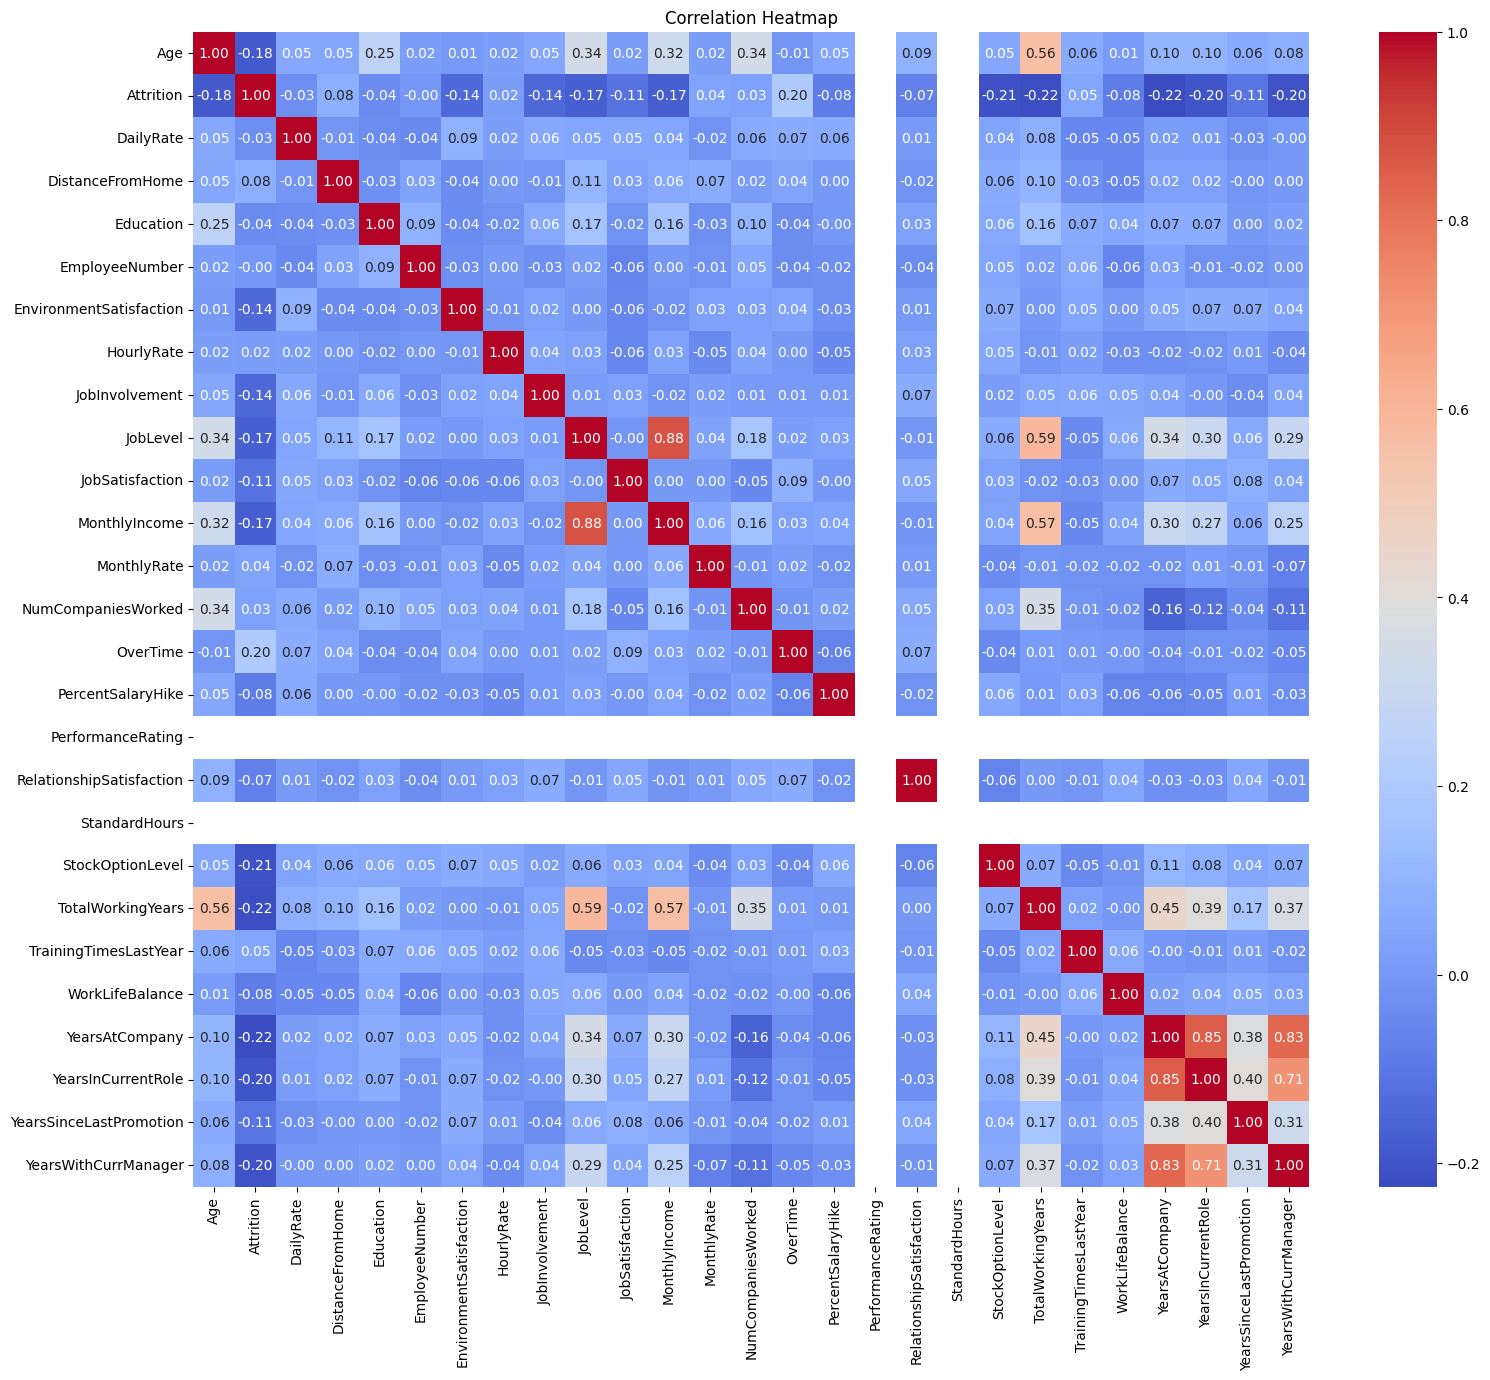

In [27]:
# Create a copy of the DataFrame to avoid modifying the original for other potential uses
df_numeric_corr = df.copy()

# Convert binary categorical columns 'Attrition' and 'OverTime' to numerical (0 or 1)
df_numeric_corr['Attrition'] = df_numeric_corr['Attrition'].map({'Yes': 1, 'No': 0})
df_numeric_corr['OverTime'] = df_numeric_corr['OverTime'].map({'Yes': 1, 'No': 0})

# Increase figure size for better readability of the heatmap
plt.figure(figsize=(18, 15))
# Calculate correlation only for numeric columns (including the newly mapped ones)
sns.heatmap(df_numeric_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##Converting Categorical data into Numerical Data

In [28]:
categorical_columns

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No
...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,No


In [29]:
## Encoding

from sklearn.preprocessing import LabelEncoder

In [30]:
le_d = {}

In [36]:
for col in categorical_columns:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  le_d[col]=le

In [38]:
le_d


{'Attrition': LabelEncoder(),
 'BusinessTravel': LabelEncoder(),
 'Department': LabelEncoder(),
 'EducationField': LabelEncoder(),
 'Gender': LabelEncoder(),
 'JobRole': LabelEncoder(),
 'MaritalStatus': LabelEncoder(),
 'OverTime': LabelEncoder()}

In [41]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1463,31,0,0,325,1,5,3,3,2057,2,...,2,80,0,10,2,3,9,4,1,7
1464,26,0,2,1167,2,5,3,4,2060,4,...,4,80,0,5,2,3,4,2,0,0
1465,36,0,1,884,1,23,2,3,2061,3,...,3,80,1,17,3,3,5,2,0,3
1468,49,0,1,1023,2,2,3,3,2065,4,...,4,80,0,17,3,2,9,6,0,8
1469,34,0,2,628,1,8,3,3,2068,2,...,1,80,0,6,3,4,4,3,1,2


## Model building

In [42]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
display((X_train.shape, X_test.shape, y_train.shape, y_test.shape))

((559, 32), (140, 32), (559,), (140,))

In [45]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((559, 32), (140, 32), (559,), (140,))

In [46]:
## Importing multiple models

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [47]:
nb = GaussianNB()
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()

In [50]:
## Training the model

# The data (X_train, y_train, X_test, y_test) is already prepared and encoded from previous steps.
# The le_d dictionary containing LabelEncoders is needed for inverse transformation.
# As le_d might have been cleared or not fully populated due to previous errors,
# let's ensure it's correctly populated with the encoders from the original dataframe's categorical columns.

# Re-initialize le_d to ensure all required encoders are present
le_d = {}
original_df_full = pd.read_csv("/content/HR_attrition.csv.csv") # Reload original for encoders

# Define the columns that were originally categorical and should have encoders in le_d
categorical_cols_for_encoder_fit = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus', 'OverTime'
]

# Re-populate le_d for consistency with the initial encoding
for col in categorical_cols_for_encoder_fit:
    le = LabelEncoder()
    le.fit(original_df_full[col].astype(str).unique())
    le_d[col] = le

# Train the models
nb.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [51]:
## Model evaluation

nb_pred = nb.predict(X_test)
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

In [52]:
## Confusion matrix print for all

print("Confusion matrix for Naive Bayes")
print(metrics.confusion_matrix(y_test, nb_pred))

Confusion matrix for Naive Bayes
[[91 26]
 [12 11]]


In [53]:
print("Confusion matrix for Random Forest")
print(metrics.confusion_matrix(y_test, rf_pred))

Confusion matrix for Random Forest
[[114   3]
 [ 21   2]]


In [54]:
print("Confusion matrix for Decision Tree")
print(metrics.confusion_matrix(y_test, dt_pred))

Confusion matrix for Decision Tree
[[100  17]
 [ 19   4]]


In [55]:
nb_acc = metrics.accuracy_score(y_test, nb_pred)
rf_acc = metrics.accuracy_score(y_test, rf_pred)
dt_acc = metrics.accuracy_score(y_test, dt_pred)

In [56]:
print("Accuracy for Naive Bayes: ", nb_acc)
print("Accuracy for Random Forest: ", rf_acc)
print("Accuracy for Decision Tree: ", dt_acc)

Accuracy for Naive Bayes:  0.7285714285714285
Accuracy for Random Forest:  0.8285714285714286
Accuracy for Decision Tree:  0.7428571428571429


In [57]:
best_model = rf

In [60]:
# Define the features provided by the user
user_provided_data = {
    'Age': [35],
    'BusinessTravel': ['Travel_Rarely'],
    'Department': ['Sales'],
    'DistanceFromHome': [10],
    'Education': [3],
    'EducationField': ['Life Sciences'],
    'Gender': ['Male'],
    'JobRole': ['Sales Executive'],
    'MaritalStatus': ['Single'],
    'MonthlyIncome': [5000],
    'OverTime': ['Yes'],
    'YearsAtCompany': [5]
}

# Create a DataFrame from user-provided data
new_data_df = pd.DataFrame(user_provided_data)

# Get all column names from the trained X (X_train has the same columns)
all_feature_columns = X_train.columns.tolist()

# Create a new DataFrame for prediction with all required columns, initialized with NaN
new_data = pd.DataFrame(columns=all_feature_columns)

# Populate new_data with the user-provided values
for col in new_data_df.columns:
    new_data[col] = new_data_df[col]

# Define default values for columns not provided by the user
# Use median for numerical and mode for categorical from original_df_full
default_values = {}
for col in all_feature_columns:
    if col not in user_provided_data:
        if original_df_full[col].dtype == 'object':
            default_values[col] = original_df_full[col].mode()[0]
        else:
            default_values[col] = original_df_full[col].median()

# Fill missing values in new_data with default values
for col, value in default_values.items():
    new_data[col].fillna(value, inplace=True)

# Ensure data types are correct before encoding, especially for categorical columns
for col in new_data.columns:
    if original_df_full[col].dtype == 'object' and col in le_d: # Check if it's a categorical column and has an encoder
        new_data[col] = new_data[col].astype(str)

# Define categorical columns to encode. Exclude 'Attrition' as it's the target and not a feature in X.
categorical_cols_to_encode = [col for col in categorical_cols_for_encoder_fit if col != 'Attrition']

# Apply Label Encoding to categorical columns in new_data
for col in categorical_cols_to_encode:
    if col in new_data.columns and col in le_d:
        new_data[col] = le_d[col].transform(new_data[col])

# Ensure the order of columns in new_data matches X_train
new_data = new_data[all_feature_columns]


In [61]:
new_data


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,35,2,802.0,2,10,3,1,1020.5,3.0,1,...,3.0,80.0,1.0,10.0,3.0,3.0,5,3.0,1.0,3.0


In [62]:
## pass this input to the best model

prediction = best_model.predict(new_data)

In [63]:
prediction

array([0])

In [64]:
## inverse transform to get the final output

print(le_d['Attrition'].inverse_transform(prediction))

['No']
